# Modelado con XGBoost
## Carga de datos

Igual que hemos hecho con el modelo anterior cargamos los datos, añadimos la colúmna de cluster y en este caso hemos decidido quedarnos con el método de k-means por su mayor comodidad a la hora de interpretarlo.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Cargar los datasets exportados
X_df = pd.read_csv('../dataset/X_vulnerabilidad_info.csv')
y = pd.read_csv('../dataset/y_vulnerabilidad.csv').squeeze() # Lo convertimos en Serie

# 2. Separar metadatos (identificadores) de las variables predictoras puras
id_cols = ['Country Name', 'Country Code', 'Time']
X_features = X_df.drop(columns=id_cols)
metadata = X_df[id_cols].copy()

# 3. Estandarizar las variables predictoras (requisito indispensable para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# 4. Aplicar Clustering de Países (K-Means)
# Probemos inicialmente con 4 clústeres (por ejemplo: Bajo, Medio-Bajo, Medio-Alto, Alto desarrollo/vulnerabilidad)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
metadata['Cluster_Pais'] = kmeans.fit_predict(X_scaled)

# 5. Integrar el Clúster como una nueva característica (Feature) en nuestra matriz X
# Convertimos el clúster a variable numérica para que el modelo predictivo pueda leerlo
X_features['Cluster_Pais'] = metadata['Cluster_Pais']

print("¡Clustering de países aplicado con éxito!")
print(metadata['Cluster_Pais'].value_counts())

¡Clustering de países aplicado con éxito!
Cluster_Pais
0    2013
3    1927
1    1520
2    1404
Name: count, dtype: int64


### Implementación de modelado de XGBoost

In [3]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, auc, mean_absolute_error, mean_absolute_percentage_error

# 6. Dividir el dataset en conjunto de entrenamiento y prueba
X_final = X_features.copy()  # Hacemos una copia para evitar modificar el original

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size = 0.2, random_state=42
)

# Entrenar el modelo base de XGBoost
modelo_base = xgb.XGBRegressor(
    random_state=42,
    n_estimators=100,
)
modelo_base.fit(X_train,y_train)

# 7. Evaluar el modelo base
y_pred = modelo_base.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"-- Evaluación del modelo base de XGBoost --")
print(f"R2 Score del modelo base: {r2:.4f}")
print(f"MSE del modelo base: {mse:.4f}")
print(f"RMSE del modelo base: {rmse:.4f}")
print(f"MAE del modelo base: {mae:.4f}")
print(f"MAPE del modelo base: {mape:.4f}")


-- Evaluación del modelo base de XGBoost --
R2 Score del modelo base: 0.9580
MSE del modelo base: 7.8599
RMSE del modelo base: 2.8035
MAE del modelo base: 1.9384
MAPE del modelo base: 0.1144


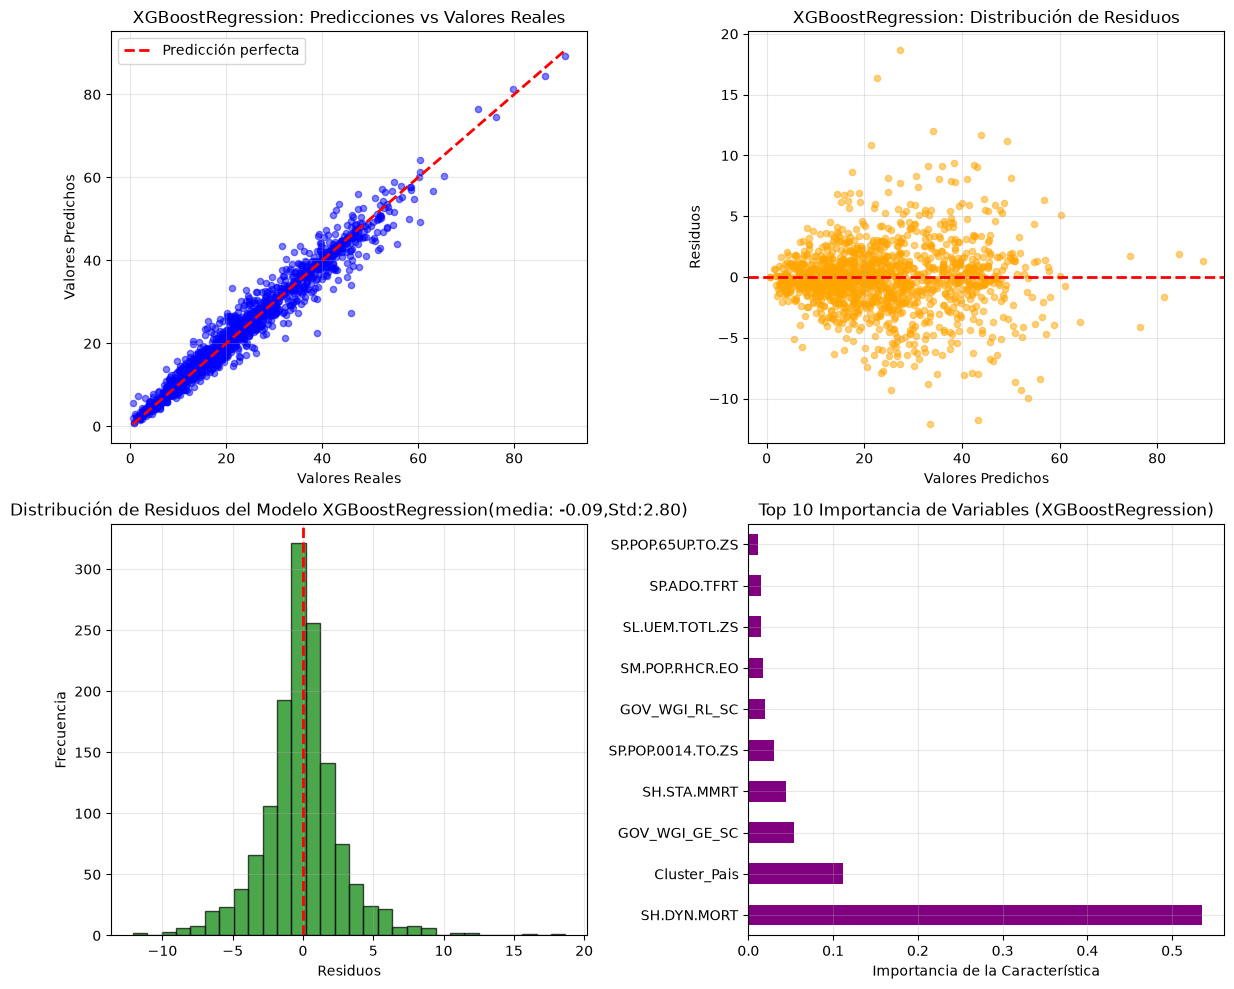



ESTADÍSTICAS FINALES DEL MODELO XGBoostRegression
Residuos promedio: -0.0905
Desviación Estándar de los Residuos: 2.8021
R2 Score del modelo base: 0.9580
Raíz del Error Cuadrático Medio (RMSE): 2.8035
Error porcentual absoluto: 11.44%


In [4]:
# 8. Visualización de la importancia de las características
fig, axes = plt.subplots(2,2, figsize=(12, 10))


# 🔵 GRÁFICA 1 (arriba-izquierda): Predicciones vs Reales
ax1 = axes[0,0]
ax1.scatter(y_test,y_pred, alpha=0.5, s=20, color='blue')
min_val = np.minimum(y_test.min(),y_pred.min())
max_val = np.maximum(y_test.max(),y_pred.max())
ax1.plot([min_val,max_val], [min_val,max_val],'r--',lw=2,label = 'Predicción perfecta')
ax1.set_xlabel('Valores Reales')
ax1.set_ylabel('Valores Predichos')
ax1.set_title('XGBoostRegression: Predicciones vs Valores Reales')    
ax1.legend()
ax1.grid(alpha=0.3)

# 🔵 GRÁFICA 2 (arriba-derecha): Distribución de Residuos
ax2 = axes[0,1]
residuos = y_test.to_numpy().flatten() - y_pred.flatten()
ax2.scatter(y_pred, residuos, alpha=0.5, s=20, color='orange')
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Valores Predichos')
ax2.set_ylabel('Residuos')
ax2.set_title('XGBoostRegression: Distribución de Residuos')
ax2.grid(alpha=0.3)

# 🔵 GRÁFICA 3 (abajo-izquierda): Histograma de Residuos
ax3 = axes[1,0]
ax3.hist(residuos, bins=30, edgecolor='black', color='green', alpha=0.7)
ax3.axvline(x=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Residuos')
ax3.set_ylabel('Frecuencia')
ax3.set_title(f'Distribución de Residuos del Modelo XGBoostRegression(media: {residuos.mean():.2f},Std:{residuos.std():.2f})')
ax3.grid(alpha=0.3)

# 🔵 GRÁFICA 4 (abajo-derecha): Importancia de Variables (Feature Importance)
ax4 = axes[1,1]
importancias = pd.Series(modelo_base.feature_importances_, index=X_final.columns)
importancias.nlargest(10).plot(kind='barh', ax=ax4, color='purple')
ax4.set_xlabel('Importancia de la Característica')
ax4.set_title('Top 10 Importancia de Variables (XGBoostRegression)')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#=======================================================
#IMPRESIÓN DE ESTADÍSTICAS FINALES
#=======================================================
error_pct_xg = np.abs((y_test.to_numpy().flatten() - y_pred.flatten()) / y_test.to_numpy().flatten() * 100)

print("\n\n=======================================================")
print("ESTADÍSTICAS FINALES DEL MODELO XGBoostRegression")
print("=======================================================")
print(f"Residuos promedio: {residuos.mean():.4f}")
print(f"Desviación Estándar de los Residuos: {residuos.std():.4f}")
print(f"R2 Score del modelo base: {r2:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f"Error porcentual absoluto: {error_pct_xg.mean():.2f}%")

In [5]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold

#=========================================================================
#OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA DEL MODELO XGBOOST
#=========================================================================

def objective(trial):
    # 1. Definirr el espacio de búsqueda de los parámetros del modelo XGBoost
    n_estimadores = trial.suggest_int('n_estimators',100, 500, step=50)
    max_depth = trial.suggest_int('max_depth', 10,50)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
    
    #colsample_bytree para evitar el sobreajuste en del modelo
    colsample_bytree = trial.suggest_categorical('colsample_bytree', [0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    
    
    #2. Instanciar el modelo con los parámetros sugeridos para optuna
    model = XGBRegressor(
        n_estimators=n_estimadores,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        colsample_bytree=colsample_bytree,
        n_jobs=-1 # para usar todos los núcleos disponibles y acelerar el proceso de entrenamiento
    )
    
    #Cross Validation para buscar optimizar R²
    
    scores = cross_val_score(model, X_train, y_train, cv = 5, scoring='r2')
    
    #Devolveos la media obtenida del R² de las 5 iteraciones de cross validation
    return scores.mean()

print("\n\n=======================================================")
print("OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA DEL MODELO XGBOOST")
print("=======================================================")

#Creamos y ejecutamos el estudio de optimización de hiperparámetros
study = optuna.create_study(direction='maximize',study_name='XGB_optimización_vulnerabilidad')

study.optimize(objective, n_trials=50)     


# ==============================================================================
# RESULTADOS FINALES DE LA OPTIMIZACIÓN
# ==============================================================================
print("\n" + "="*50)
print("OPTIMIZACIÓN COMPLETADA")
print("="*50)
print(f"Mejor valor R² (Media de CV): {study.best_value:.4f}")
print("Mejores hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"    - {key}: {value}")
print("="*50)

c:\Users\javie\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-20 13:51:26,003] A new study created in memory with name: XGB_optimización_vulnerabilidad




OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA DEL MODELO XGBOOST


[I 2026-08-20 13:51:40,622] Trial 0 finished with value: 0.9533669015441786 and parameters: {'n_estimators': 400, 'max_depth': 11, 'min_child_weight': 2, 'colsample_bytree': 0.5}. Best is trial 0 with value: 0.9533669015441786.
[I 2026-08-20 13:52:23,003] Trial 1 finished with value: 0.9557212317906615 and parameters: {'n_estimators': 300, 'max_depth': 48, 'min_child_weight': 10, 'colsample_bytree': 0.6}. Best is trial 1 with value: 0.9557212317906615.
[I 2026-08-20 13:54:07,973] Trial 2 finished with value: 0.9514099886682439 and parameters: {'n_estimators': 100, 'max_depth': 28, 'min_child_weight': 2, 'colsample_bytree': 1.0}. Best is trial 1 with value: 0.9557212317906615.
[I 2026-08-20 13:54:56,360] Trial 3 finished with value: 0.9529207035759166 and parameters: {'n_estimators': 500, 'max_depth': 46, 'min_child_weight': 6, 'colsample_bytree': 0.5}. Best is trial 1 with value: 0.9557212317906615.
[I 2026-08-20 13:56:21,622] Trial 4 finished with value: 0.948083261654349 and paramete


OPTIMIZACIÓN COMPLETADA
Mejor valor R² (Media de CV): 0.9598
Mejores hiperparámetros encontrados:
    - n_estimators: 300
    - max_depth: 10
    - min_child_weight: 10
    - colsample_bytree: 0.9


In [6]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
import numpy as np

# ==============================================================================
# 1. ENTRENAMIENTO DEL MODELO DEFINITIVO CON OPTUNA
# ==============================================================================
print("Entrenamiento con los mejores parámetros encontrados...")

best_params = study.best_params
modelo_opt = XGBRegressor(
    **best_params,
    n_jobs=-1,
    random_state=42
)

modelo_optimizado = modelo_opt.fit(X_train, y_train)


pred_opt = modelo_optimizado.predict(X_test)

# ==============================================================================
# 2. CÁLCULO DEL ERROR PORCENTUAL ABSOLUTO (Y OTRAS MÉTRICAS)
# ==============================================================================
mape_opt = mean_absolute_percentage_error(y_test, pred_opt) * 100

r2_opt = r2_score(y_test, pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, pred_opt))

#cálculo manual del array de errores porcentuales para ver el máximo y mínimo
epsilon = 1e-10
y_test_array = y_test.to_numpy().flatten()
error_pct_absoluto_opt = np.abs((y_test_array - pred_opt) / (y_test_array + epsilon)) * 100

# ==============================================================================
# IMPRESIÓN DE RESULTADOS DEL MODELO OPTIMIZADO
# ==============================================================================
print("\n" + "="*50)
print("RENDIMIENTO DEL MODELO OPTIMIZADO (TEST SET)")
print("="*50)
print(f"R² Score Optimizado  : {r2_opt:.4f}")
print(f"RMSE Optimizado      : {rmse_opt:.4f}")
print("-" * 50)
print(f"Error Porcentual Absoluto Medio (MAPE) : {mape_opt:.2f}%")
print(f"Error porcentual máximo en predicción  : {error_pct_absoluto_opt.max():.2f}%")
print(f"Error porcentual mínimo en predicción  : {error_pct_absoluto_opt.min():.2f}%")
print("="*50)

Entrenamiento con los mejores parámetros encontrados...

RENDIMIENTO DEL MODELO OPTIMIZADO (TEST SET)
R² Score Optimizado  : 0.9543
RMSE Optimizado      : 2.9259
--------------------------------------------------
Error Porcentual Absoluto Medio (MAPE) : 10.38%
Error porcentual máximo en predicción  : 410.44%
Error porcentual mínimo en predicción  : 0.00%
